<a href="https://colab.research.google.com/github/devabhinavraj/BreastQNet/blob/main/GAE_QCNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

In [ ]:
import os, random, subprocess, sys
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
from sklearn.model_selection import train_test_split

# Install PennyLane
subprocess.run([sys.executable, "-m", "pip", "install", "pennylane", "pennylane-lightning", "-q"])

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pennylane as qml

torch.set_default_dtype(torch.float32)
print("TensorFlow :", tf.__version__)
print("PyTorch    :", torch.__version__)
print("PennyLane  :", qml.__version__)

TensorFlow : 2.19.0
PyTorch    : 2.10.0+cpu
PennyLane  : 0.44.1


# Dataset Setup (Google Colab)

The BreaKHis dataset is available at: https://www.kaggle.com/datasets/anaselmasry/breast-cancer-dataset

### How to get the dataset in Colab:

**Option A — Kaggle API (recommended):**
```python
from google.colab import files
files.upload()  # upload your kaggle.json
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d anaselmasry/breast-cancer-dataset --unzip -p /content/
```

**Option B — Manual upload:**  
Upload the zip via the Colab sidebar, then unzip with `!unzip breast-cancer-dataset.zip -d /content/`

**Option C — Google Drive:**  
Mount Drive and set `DATASET_PATH` manually.


In [ ]:
import os

# ── Install Kaggle API ────────────────────────────────────────
!pip install kaggle -q

# ── Write kaggle.json directly (no file upload needed) ───────
# Just paste your Kaggle username and API key here
KAGGLE_USERNAME = "your_username_here"   # ← change this
KAGGLE_KEY      = "your_api_key_here"    # ← change this

os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "w") as f:
    f.write(f'{{"username":"{KAGGLE_USERNAME}","key":"{KAGGLE_KEY}"}}')
os.chmod("/root/.kaggle/kaggle.json", 0o600)

# ── Download directly from Kaggle to Colab ───────────────────
!kaggle datasets download -d anaselmasry/breast-cancer-dataset -p /content/ --unzip

print("Done! Dataset downloaded.")

Dataset URL: https://www.kaggle.com/datasets/anaselmasry/breast-cancer-dataset
License(s): copyright-authors
100% 3.93G/3.93G [00:47<00:00, 88.1MB/s]

Done! Dataset downloaded.


In [ ]:
import os, gdown
from pathlib import Path

# ── Step 1: Mount Google Drive (optional — skip if not using Drive) ──
# from google.colab import drive
# drive.mount('/content/drive')

# ── Step 2: Download BreaKHis dataset from Kaggle ────────────────────
# Option A — via Kaggle API (recommended)
# Upload your kaggle.json first, then run:
#   from google.colab import files; files.upload()   # upload kaggle.json
#   !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
#   !kaggle datasets download -d anaselmasry/breast-cancer-dataset --unzip -p /content/

# Option B — if dataset is already on Google Drive, set the path below:
# DATASET_PATH = Path("/content/drive/MyDrive/BreaKHis_Total_dataset")

# ── Step 3: Auto-detect dataset root ─────────────────────────────────
def find_dataset_root(search_base="/content"):
    for root, dirs, files in os.walk(search_base):
        root = Path(root)
        if (root / "benign").exists() and (root / "malignant").exists():
            return root
    return None

DATASET_PATH = find_dataset_root("/content")

if DATASET_PATH is None:
    print("Dataset NOT found under /content.")
    print("Please do ONE of the following:")
    print("  A) Run the Kaggle API download commands above (Option A)")
    print("  B) Upload the dataset zip manually and unzip it")
    print("  C) Mount Google Drive and set DATASET_PATH manually (Option B)")
    raise FileNotFoundError("Dataset not found. See instructions above.")
else:
    print("Dataset found at:", DATASET_PATH)

benign_images    = list((DATASET_PATH / "benign").glob("*.*"))
malignant_images = list((DATASET_PATH / "malignant").glob("*.*"))

print("Benign images   :", len(benign_images))
print("Malignant images:", len(malignant_images))


Dataset found at: /content/BreaKHis_Total_dataset
Benign images   : 2479
Malignant images: 5304


### Data Balancing + Sample, Split & TF Pipeline

In [ ]:
random.seed(42)
np.random.seed(42)

# ── Data Balancing ────────────────────────────────────────────
# Oversample benign to 2500, undersample malignant to 2500
TARGET = 2500

# Benign — oversample (sample with replacement if needed)
if len(benign_images) >= TARGET:
    benign_sampled = random.sample(benign_images, TARGET)
else:
    # oversample with replacement
    benign_sampled = random.choices(benign_images, k=TARGET)

# Malignant — undersample to 2500
malignant_sampled = random.sample(malignant_images, min(len(malignant_images), TARGET))

print(f"Balanced Benign   : {len(benign_sampled)}")
print(f"Balanced Malignant: {len(malignant_sampled)}")

# ── Build file / label lists ──────────────────────────────────
files, labels = [], []
for f in benign_sampled:
    files.append(str(f)); labels.append(0)
for f in malignant_sampled:
    files.append(str(f)); labels.append(1)

assert len(files) > 0, "files list is empty — check dataset path!"
print(f"Total images: {len(files)}")

# ── Train / Val / Test split ──────────────────────────────────
files_np  = np.array(files)
labels_np = np.array(labels)

train_files, test_files, train_labels, test_labels = train_test_split(
    files_np, labels_np, test_size=0.15, random_state=42, stratify=labels_np
)
train_files, val_files, train_labels, val_labels = train_test_split(
    train_files, train_labels, test_size=0.15, random_state=42, stratify=train_labels
)
print(f"Train: {len(train_files)} | Val: {len(val_files)} | Test: {len(test_files)}")

# ── TF data pipeline ──────────────────────────────────────────
IMG_SIZE = (128, 128)

def preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def create_dataset(files, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((files, labels))
    if shuffle:
        ds = ds.shuffle(len(files), seed=42)
    ds = ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(32).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = create_dataset(train_files, train_labels, shuffle=True)
val_ds   = create_dataset(val_files,   val_labels)
test_ds  = create_dataset(test_files,  test_labels)
print("Datasets ready.")

Balanced Benign   : 2500
Balanced Malignant: 2500
Total images: 5000
Train: 3612 | Val: 638 | Test: 750
Datasets ready.


### Visualise a Batch

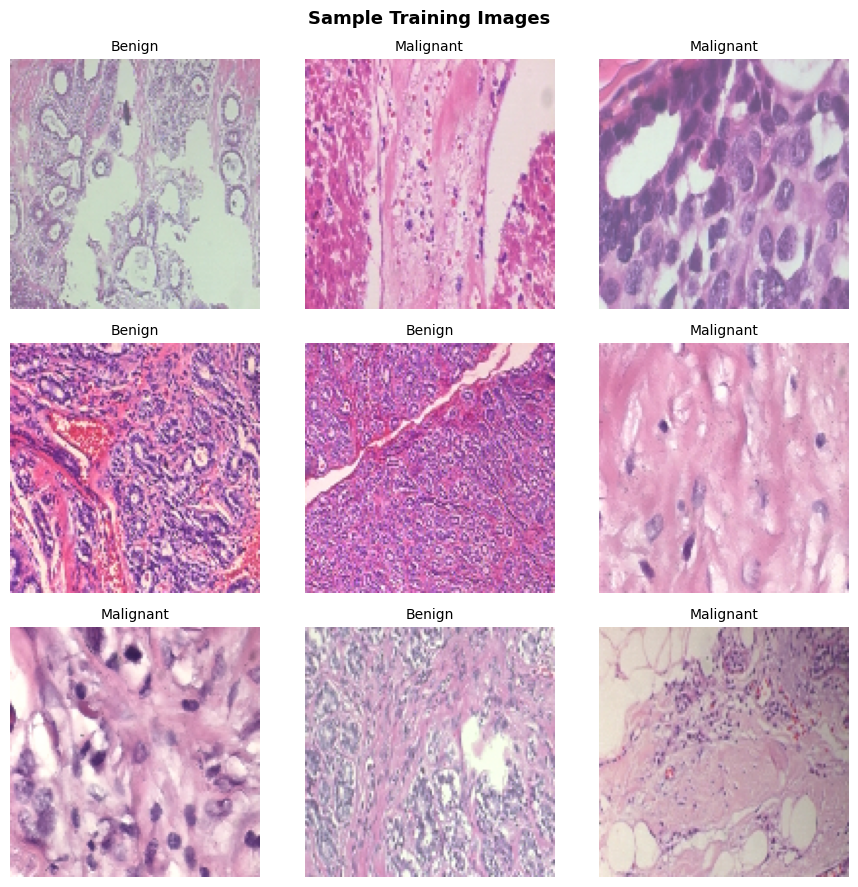

In [ ]:
plt.figure(figsize=(9, 9))
for images, lbls in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        plt.title("Benign" if lbls[i] == 0 else "Malignant", fontsize=10)
        plt.axis("off")
plt.suptitle("Sample Training Images", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Classical CNN Baseline

Model: "Classical_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 105s 899ms/step - accuracy: 0.7004 - loss: 0.5753 - val_accuracy: 0.8009 - val_loss: 0.4716
Epoch 2/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 93s 817ms/step - accuracy: 0.7926 - loss: 0.4840 - val_accuracy: 0.7806 - val_loss: 0.4924
Epoch 3/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 142s 813ms/step - accuracy: 0.8020 - loss: 0.4769 - val_accuracy: 0.8339 - val_loss: 0.4331
Epoch 4/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 94s 827ms/step - accuracy: 0.8167 - loss: 0.4427 - val_accuracy: 0.7962 - val_loss: 0.4566
Epoch 5/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 91s 807ms/step - accuracy: 0.8095 - loss: 0.4529 - val_accuracy: 0.7335 - val_loss: 0.5254
Epoch 6/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 90s 778ms/step - accuracy: 0.8189 - loss: 0.4329 - val_accuracy: 0.8401 - val_loss: 0.4119
Epoch 7/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 146s 824ms/step - accuracy: 0.8225 - loss: 0.4227 - val_accuracy: 0.7571 - val_loss: 0.5259
Epoch 8/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 88s 780ms/step - accuracy: 0.8283 - loss

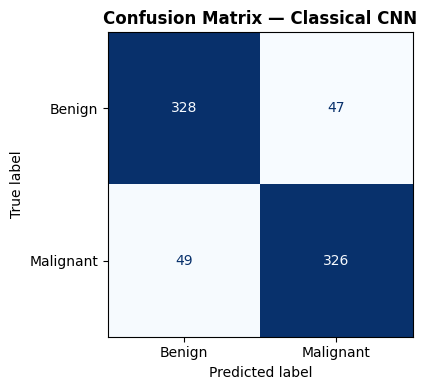

In [ ]:

baseline_model = tf.keras.Sequential([
    tf.keras.Input(shape=(128, 128, 3)),
    tf.keras.layers.Conv2D(32, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
], name="Classical_CNN")

baseline_model.compile(optimizer="adam", loss="binary_crossentropy",
                        metrics=["accuracy"])
baseline_model.summary()

baseline_history = baseline_model.fit(
    train_ds, validation_data=val_ds, epochs=20, verbose=1)

_, baseline_acc = baseline_model.evaluate(test_ds, verbose=0)
print(f"\nClassical CNN — Test Accuracy: {baseline_acc*100:.2f}%")

# ── Full Metrics for Classical CNN ────────────────────────────
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay)

# Get predictions
all_preds_cnn  = []
all_labels_cnn = []
for imgs, lbls in test_ds:
    preds = baseline_model.predict(imgs, verbose=0)
    preds = (preds > 0.5).astype(int).flatten()
    all_preds_cnn.extend(preds)
    all_labels_cnn.extend(lbls.numpy().astype(int).flatten())

all_preds_cnn  = np.array(all_preds_cnn)
all_labels_cnn = np.array(all_labels_cnn)

cnn_accuracy  = accuracy_score(all_labels_cnn, all_preds_cnn)  * 100
cnn_precision = precision_score(all_labels_cnn, all_preds_cnn, zero_division=0) * 100
cnn_recall    = recall_score(all_labels_cnn, all_preds_cnn,    zero_division=0) * 100
cnn_f1        = f1_score(all_labels_cnn, all_preds_cnn,        zero_division=0) * 100
cnn_cm        = confusion_matrix(all_labels_cnn, all_preds_cnn)

print(f"\n{'='*50}")
print(f"  Metrics for: Classical CNN")
print(f"{'='*50}")
print(f"  Accuracy  : {cnn_accuracy:.2f}%")
print(f"  Precision : {cnn_precision:.2f}%")
print(f"  Recall    : {cnn_recall:.2f}%")
print(f"  F1 Score  : {cnn_f1:.2f}%")
print(f"{'='*50}")

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cnn_cm,
                               display_labels=["Benign", "Malignant"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — Classical CNN", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix_Classical_CNN.png", dpi=150, bbox_inches="tight")
plt.show()

# Store for final comparison
classical_metrics = {"accuracy": cnn_accuracy, "precision": cnn_precision,
                     "recall": cnn_recall, "f1": cnn_f1}


###  Shared Helpers + Same PyTorch Conv Block

In [ ]:
# ── Convert TF → PyTorch ──────────────────────────────────────
def tf_to_numpy(dataset):
    imgs, lbls = [], []
    for x, y in dataset:
        imgs.append(x.numpy()); lbls.append(y.numpy())
    return np.concatenate(imgs), np.concatenate(lbls)

X_train_np, y_train_np = tf_to_numpy(train_ds)
X_val_np,   y_val_np   = tf_to_numpy(val_ds)
X_test_np,  y_test_np  = tf_to_numpy(test_ds)

def to_torch(X, y):
    Xt = torch.tensor(X, dtype=torch.float32).permute(0,3,1,2)
    yt = torch.tensor(y, dtype=torch.float32)
    return Xt, yt

X_train_t, y_train_t = to_torch(X_train_np, y_train_np)
X_val_t,   y_val_t   = to_torch(X_val_np,   y_val_np)
X_test_t,  y_test_t  = to_torch(X_test_np,  y_test_np)

print("X_train:", X_train_t.shape)
print("X_val  :", X_val_t.shape)
print("X_test :", X_test_t.shape)

BATCH = 16
trainloader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH, shuffle=True)
valloader   = DataLoader(TensorDataset(X_val_t,   y_val_t),   batch_size=BATCH, shuffle=False)
testloader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=BATCH, shuffle=False)

# ── SHARED Conv Block ─────────────────────────────────────────
def build_conv_block():
    return nn.Sequential(
        nn.Conv2d(3, 16, kernel_size=3, padding=1),
        nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(16, 32, kernel_size=3, padding=1),
        nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(32, 32, kernel_size=3, padding=1),
        nn.BatchNorm2d(32), nn.ReLU(),
        nn.AdaptiveAvgPool2d((4, 4))
    )

CONV_OUT_DIM = 32 * 4 * 4

# ── Keras-style progress bar training ────────────────────────
import sys, time

def keras_progress_bar(current, total, bar_length=30):
    """Prints a Keras-style green progress bar."""
    filled   = int(bar_length * current / total)
    bar      = "=" * filled + (">" if filled < bar_length else "") + "." * (bar_length - filled - (1 if filled < bar_length else 0))
    return f"{current}/{total} [{bar}]"

def train_qcnn(model, epochs=20, lr=0.001, label="Model"):
    """
    Trains model with Keras-style progress bar output.
    Shows: epoch, progress bar, time, loss, accuracy, val_accuracy.
    """
    criterion  = nn.BCELoss()
    optimizer  = optim.Adam(model.parameters(), lr=lr)
    train_accs = []
    val_accs   = []
    total_batches = len(trainloader)

    print(f"\nTraining: {label}")
    for epoch in range(epochs):
        model.train()
        running_loss    = 0.0
        correct         = 0
        total           = 0
        epoch_start     = time.time()

        for batch_idx, (imgs, lbls) in enumerate(trainloader):
            lbls = lbls.unsqueeze(1)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss    = criterion(outputs, lbls)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            predicted     = (outputs > 0.5).float()
            correct      += (predicted == lbls).sum().item()
            total        += lbls.size(0)

            # Print live progress bar every 10 batches
            if (batch_idx + 1) % 10 == 0 or (batch_idx + 1) == total_batches:
                elapsed  = time.time() - epoch_start
                ms_step  = int((elapsed / (batch_idx + 1)) * 1000)
                bar      = keras_progress_bar(batch_idx + 1, total_batches)
                acc      = correct / total
                avg_loss = running_loss / (batch_idx + 1)
                print(f"\rEpoch {epoch+1}/{epochs}\n"
                      f"{bar} - {int(elapsed)}s {ms_step}ms/step"
                      f" - accuracy: {acc:.4f}"
                      f" - loss: {avg_loss:.4f}",
                      end="", flush=True)

        # Validation
        model.eval()
        val_correct = val_total = 0
        val_loss_sum = 0.0
        with torch.no_grad():
            for imgs, lbls in valloader:
                lbls     = lbls.unsqueeze(1)
                outputs  = model(imgs)
                val_loss_sum += criterion(outputs, lbls).item()
                predicted = (outputs > 0.5).float()
                val_correct += (predicted == lbls).sum().item()
                val_total   += lbls.size(0)

        train_acc = correct / total
        val_acc   = val_correct / val_total
        avg_loss  = running_loss / total_batches
        avg_val_loss = val_loss_sum / len(valloader)
        elapsed   = time.time() - epoch_start

        # Final epoch line (Keras style)
        bar = keras_progress_bar(total_batches, total_batches)
        ms_step = int((elapsed / total_batches) * 1000)
        print(f"\rEpoch {epoch+1}/{epochs}\n"
              f"{bar} - {int(elapsed)}s {ms_step}ms/step"
              f" - accuracy: {train_acc:.4f}"
              f" - loss: {avg_loss:.4f}"
              f" - val_accuracy: {val_acc:.4f}"
              f" - val_loss: {avg_val_loss:.4f}")

        train_accs.append(train_acc * 100)
        val_accs.append(val_acc * 100)

    return train_accs, val_accs

# ── Evaluate accuracy ─────────────────────────────────────────
def evaluate_model(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, lbls in loader:
            lbls  = lbls.unsqueeze(1)
            out   = model(imgs)
            pred  = (out > 0.5).float()
            correct += (pred == lbls).sum().item()
            total   += lbls.size(0)
    return 100.0 * correct / total

# ── Full metrics: accuracy, precision, recall, F1, confusion matrix ──
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay)

def evaluate_full_metrics(model, loader, model_name="Model"):
    """
    Computes and prints:
      - Accuracy, Precision, Recall, F1 Score
      - Confusion Matrix (plotted)
    """
    model.eval()
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for imgs, lbls in loader:
            lbls    = lbls.unsqueeze(1)
            outputs = model(imgs)
            preds   = (outputs > 0.5).float()
            all_preds.extend(preds.cpu().numpy().flatten())
            all_labels.extend(lbls.cpu().numpy().flatten())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    accuracy  = accuracy_score(all_labels, all_preds)  * 100
    precision = precision_score(all_labels, all_preds, zero_division=0) * 100
    recall    = recall_score(all_labels, all_preds,    zero_division=0) * 100
    f1        = f1_score(all_labels, all_preds,        zero_division=0) * 100
    cm        = confusion_matrix(all_labels, all_preds)

    # Print metrics table
    print(f"\n{'='*50}")
    print(f"  Metrics for: {model_name}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {accuracy:.2f}%")
    print(f"  Precision : {precision:.2f}%")
    print(f"  Recall    : {recall:.2f}%")
    print(f"  F1 Score  : {f1:.2f}%")
    print(f"{'='*50}")

    # Plot confusion matrix
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Benign", "Malignant"]
    )
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion Matrix — {model_name}",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"confusion_matrix_{model_name.replace(' ', '_')}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

    return {"accuracy": accuracy, "precision": precision,
            "recall": recall, "f1": f1, "cm": cm}

# ── Feature importance alpha ──────────────────────────────────
N_QUBITS = 4
X_flat   = X_train_t.reshape(X_train_t.shape[0], -1)
feat_var = torch.var(X_flat, dim=0)
alpha    = (feat_var[:N_QUBITS] / feat_var[:N_QUBITS].max()).float()
print("Alpha:", alpha)
print("Conv output dim:", CONV_OUT_DIM)
print("All shared components ready!")


X_train: torch.Size([3612, 3, 128, 128])
X_val  : torch.Size([638, 3, 128, 128])
X_test : torch.Size([750, 3, 128, 128])
Alpha: tensor([0.9968, 0.9953, 1.0000, 0.9657])
Conv output dim: 512
All shared components ready!


## Baseline QNN

Baseline QCNN | Params: 16593

Training: Baseline-QCNN
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
226/226 [==============================] - 134s 596ms/step - accuracy: 0.7760 - loss: 0.5440 - val_accuracy: 0.7947 - val_loss: 0.4882
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
226/226 [==============================] - 132s 586ms/step - accuracy: 0.8187 - loss: 0.4569 - val_accuracy: 0.8166 - val_loss: 0.4387
Epoch 3/20
Epoch 3/20
Epoch 3/20
Epoch 3/20
Epoch 3/20
Epoch 3/20
Epoch 3/20
Epoch 3/20
Epoch 3/20
Epoch 3/20
Epoch 3/20
Epoch 3/20
Epoch 3/20
Epoc

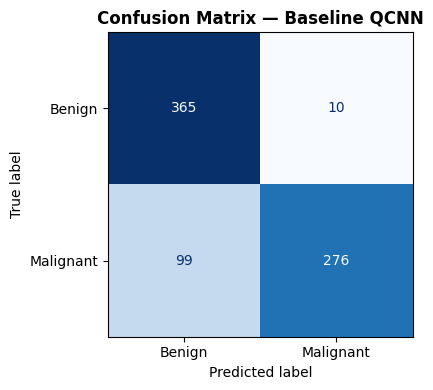

In [ ]:
N_QB   = N_QUBITS
dev_base = qml.device("default.qubit", wires=N_QB)

@qml.qnode(dev_base, interface="torch")
def qcirc_base(inputs, weights, enc_w):
    for i in range(N_QB):
        theta = enc_w[i] * inputs[i] * alpha[i]
        qml.RY(theta, wires=i)
        qml.RZ(theta, wires=i)
    qml.StronglyEntanglingLayers(weights, wires=range(N_QB))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QB)]

class QuantumLayer_Base(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(0.01 * torch.randn(3, N_QB, 3))
        self.enc_w   = nn.Parameter(torch.ones(N_QB))
    def forward(self, x):
        return torch.stack([
            torch.stack(qcirc_base(x[i], self.weights, self.enc_w)).float()
            for i in range(x.shape[0])
        ])

class HybridQCNN_Base(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv    = build_conv_block()
        self.fc1     = nn.Linear(CONV_OUT_DIM, N_QB)
        self.quantum = QuantumLayer_Base()
        self.fc2     = nn.Linear(N_QB, 1)
    def forward(self, x):
        x = self.conv(x)
        x = x.reshape(x.size(0), -1)
        x = torch.tanh(self.fc1(x)) * np.pi
        x = self.quantum(x)
        return torch.sigmoid(self.fc2(x))

model_base = HybridQCNN_Base()
print("Baseline QCNN | Params:", sum(p.numel() for p in model_base.parameters()))
train_acc_base, val_acc_base = train_qcnn(model_base, epochs=20, label="Baseline-QCNN")
test_acc_base = evaluate_model(model_base, testloader)
print(f"\nBaseline QCNN — Test Accuracy: {test_acc_base:.2f}%")

# ── Full Metrics ──────────────────────────────────────────────
baseline_metrics = evaluate_full_metrics(model_base, testloader, "Baseline QCNN")


# Improvements to the Quantum Circuit

## Multi-Branch Quantum CNN (Fixed Encoding)

In [ ]:
# ── Method 5: Multi-Branch QCNN (Fixed — all encodings present) ──
N_Q5 = 4
dev_texture = qml.device("default.qubit", wires=N_Q5)
dev_edge    = qml.device("default.qubit", wires=N_Q5)
dev_global  = qml.device("default.qubit", wires=N_Q5)

alpha_m5 = alpha   # reuse shared feature importance

# ── Circuit 1: Texture — RY+RZ angle encoding ────────────────
@qml.qnode(dev_texture, interface="torch")
def circuit_texture(inputs, weights, enc_w):
    # Encoding: learned weighted angle embedding
    for i in range(N_Q5):
        theta = enc_w[i] * inputs[i] * alpha_m5[i]
        qml.RY(theta * np.pi,     wires=i)    # texture → high freq RY
        qml.RZ(theta * np.pi / 2, wires=i)    # phase shift RZ
    qml.StronglyEntanglingLayers(weights, wires=range(N_Q5))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_Q5)]

# ── Circuit 2: Edge — Hadamard + CNOT + AngleEmbedding ───────
@qml.qnode(dev_edge, interface="torch")
def circuit_edge(inputs, weights, enc_w):
    # Encoding: Hadamard superposition + angle embedding for edges
    qml.AngleEmbedding(inputs * alpha_m5, wires=range(N_Q5), rotation="X")
    for i in range(N_Q5):
        qml.Hadamard(wires=i)
        qml.RZ(enc_w[i] * inputs[i], wires=i)   # edge phase encoding
    for i in range(N_Q5 - 1):
        qml.CNOT(wires=[i, i+1])                 # entangle neighbors
    qml.StronglyEntanglingLayers(weights, wires=range(N_Q5))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_Q5)]

# ── Circuit 3: Global — full AngleEmbedding on all axes ──────
@qml.qnode(dev_global, interface="torch")
def circuit_global(inputs, weights, enc_w):
    # Encoding: full AngleEmbedding (X + Y rotation = global context)
    qml.AngleEmbedding(inputs * alpha_m5, wires=range(N_Q5), rotation="X")
    qml.AngleEmbedding(inputs * enc_w,    wires=range(N_Q5), rotation="Y")
    qml.StronglyEntanglingLayers(weights, wires=range(N_Q5))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_Q5)]

class MultiBranchQuantumLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.w_texture = nn.Parameter(0.01 * torch.randn(3, N_Q5, 3))
        self.w_edge    = nn.Parameter(0.01 * torch.randn(3, N_Q5, 3))
        self.w_global  = nn.Parameter(0.01 * torch.randn(3, N_Q5, 3))
        self.enc_texture = nn.Parameter(torch.ones(N_Q5))
        self.enc_edge    = nn.Parameter(torch.ones(N_Q5))
        self.enc_global  = nn.Parameter(torch.ones(N_Q5))

    def forward(self, x):
        tex, edg, glb = [], [], []
        for i in range(x.shape[0]):
            tex.append(torch.stack(circuit_texture(x[i], self.w_texture, self.enc_texture)).float())
            edg.append(torch.stack(circuit_edge   (x[i], self.w_edge,    self.enc_edge   )).float())
            glb.append(torch.stack(circuit_global (x[i], self.w_global,  self.enc_global )).float())
        return torch.cat([
            torch.stack(tex),
            torch.stack(edg),
            torch.stack(glb)
        ], dim=1)   # → [batch, N_Q5 * 3]

class QCNN_M5(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv    = build_conv_block()              # shared conv block
        self.fc1     = nn.Linear(CONV_OUT_DIM, N_Q5)
        self.quantum = MultiBranchQuantumLayer()
        self.fc2     = nn.Linear(N_Q5 * 3, 16)
        self.fc3     = nn.Linear(16, 1)
        self.dropout = nn.Dropout(0.3)
    def forward(self, x):
        x = self.conv(x)
        x = x.reshape(x.size(0), -1)
        x = torch.tanh(self.fc1(x)) * np.pi
        x = self.quantum(x)
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        return torch.sigmoid(self.fc3(x))

model_m5 = QCNN_M5()
print("Method 5 — Multi-Branch QCNN | Params:", sum(p.numel() for p in model_m5.parameters()))
train_acc_m5, val_acc_m5 = train_qcnn(model_m5, epochs=20, label="M5-MultiBranch")
test_acc_m5 = evaluate_model(model_m5, testloader)
print(f"\nMethod 5 (Multi-Branch) — Test Accuracy: {test_acc_m5:.2f}%")

Method 5 — Multi-Branch QCNN | Params: 16893

Training: M5-MultiBranch
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
226/226 [==============================] - 348s 1543ms/step - accuracy: 0.6711 - loss: 0.6159 - val_accuracy: 0.7288 - val_loss: 0.5203
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
226/226 [==============================] - 345s 1527ms/step - accuracy: 0.7838 - loss: 0.4850 - val_accuracy: 0.7288 - val_loss: 0.5442
Epoch 3/20
Epoch 3/20
Epoch 3/20
Epoch 3/20
Epoch 3/20
Epoch 3/20
Epoch 3/20
Epoch 3/20
Epoch 3/20
Epoch 3/20
Epoch 3/20
Epoch 3/


  Metrics for: M5 Multi-Branch QCNN
  Accuracy  : 82.40%
  Precision : 76.82%
  Recall    : 92.80%
  F1 Score  : 84.06%


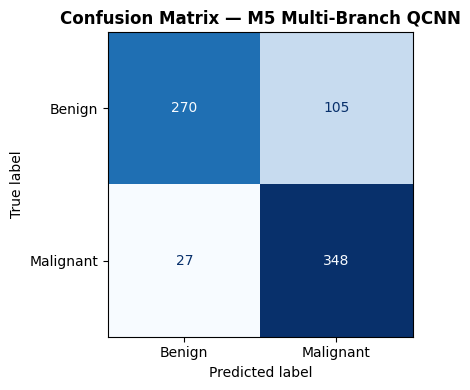

In [ ]:

# ── Full Metrics for Method 5 ────────────────────────────────
metrics_m5 = evaluate_full_metrics(model_m5, testloader, "M5 Multi-Branch QCNN")


## Explainable Quantum CNN

Method 6 — Explainable QCNN | Params: 16593

Training: M6-Explainable
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
226/226 [==============================] - 141s 627ms/step - accuracy: 0.7973 - loss: 0.5274 - val_accuracy: 0.7179 - val_loss: 0.5773
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
Epoch 2/20
226/226 [==============================] - 141s 624ms/step - accuracy: 0.8167 - loss: 0.4564 - val_accuracy: 0.8213 - val_loss: 0.4506
Epoch 3/20
Epoch 3/20
Epoch 3/20
Epoch 3/20
Epoch 3/20
Epoch 3/20
Epoch 3/20
Epoch 3/20
Epoch 3/20
Epoch 3/20
Epoch 3/20
Epoch 3/20


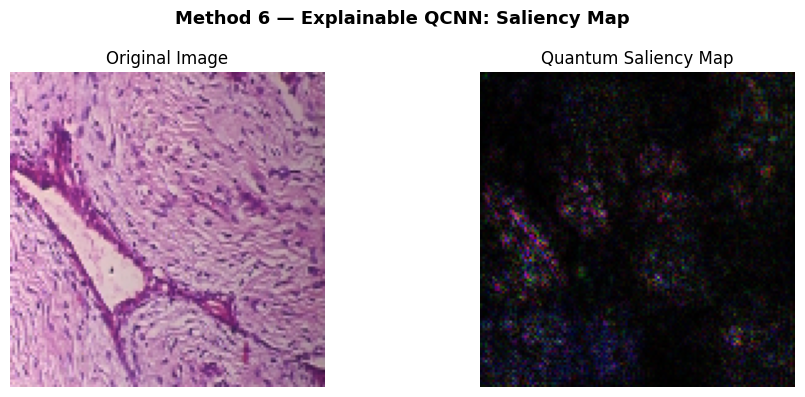

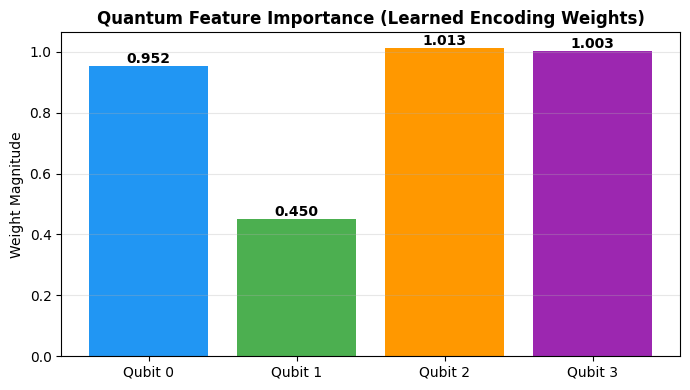

In [ ]:
N_Q6   = 4
dev_m6 = qml.device("default.qubit", wires=N_Q6)
alpha_m6 = alpha

@qml.qnode(dev_m6, interface="torch")
def qcirc_m6(inputs, weights, enc_w):
    for i in range(N_Q6):
        theta = enc_w[i] * inputs[i] * alpha_m6[i]
        qml.RY(theta, wires=i)
        qml.RZ(theta, wires=i)
    qml.StronglyEntanglingLayers(weights, wires=range(N_Q6))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_Q6)]

class QuantumLayer_M6(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(0.01 * torch.randn(3, N_Q6, 3))
        self.enc_w   = nn.Parameter(torch.ones(N_Q6))
    def forward(self, x):
        return torch.stack([
            torch.stack(qcirc_m6(x[i], self.weights, self.enc_w)).float()
            for i in range(x.shape[0])
        ])

class QCNN_M6(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv    = build_conv_block()          # shared conv block
        self.fc1     = nn.Linear(CONV_OUT_DIM, N_Q6)
        self.quantum = QuantumLayer_M6()
        self.fc2     = nn.Linear(N_Q6, 1)
    def forward(self, x):
        x = self.conv(x)
        x = x.reshape(x.size(0), -1)              # reshape fixes saliency bug
        x = torch.tanh(self.fc1(x)) * np.pi
        x = self.quantum(x)
        return torch.sigmoid(self.fc2(x))

model_m6 = QCNN_M6()
print("Method 6 — Explainable QCNN | Params:", sum(p.numel() for p in model_m6.parameters()))
train_acc_m6, val_acc_m6 = train_qcnn(model_m6, epochs=20, label="M6-Explainable")
test_acc_m6 = evaluate_model(model_m6, testloader)
print(f"\nMethod 6 (Explainable QCNN) — Test Accuracy: {test_acc_m6:.2f}%")

# ── Quantum Saliency Map ──────────────────────────────────────
print("\nComputing Quantum Saliency Map...")
model_m6.eval()
sample_img = X_test_t[0:1].clone().detach().requires_grad_(True)
output = model_m6(sample_img)
output.backward()

saliency = sample_img.grad.data.abs()
saliency = saliency.squeeze().permute(1, 2, 0).numpy()
saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(X_test_t[0].permute(1, 2, 0).numpy())
axes[0].set_title("Original Image", fontsize=12)
axes[0].axis("off")
axes[1].imshow(saliency, cmap="hot")
axes[1].set_title("Quantum Saliency Map", fontsize=12)
axes[1].axis("off")
plt.suptitle("Method 6 — Explainable QCNN: Saliency Map",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("saliency_map.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Quantum Feature Importance ────────────────────────────────
enc_weights   = model_m6.quantum.enc_w.detach().numpy()
feature_names = [f"Qubit {i}" for i in range(N_Q6)]

plt.figure(figsize=(7, 4))
bars = plt.bar(feature_names, np.abs(enc_weights),
               color=["#2196F3","#4CAF50","#FF9800","#9C27B0"])
for bar, val in zip(bars, enc_weights):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")
plt.title("Quantum Feature Importance (Learned Encoding Weights)",
          fontsize=12, fontweight="bold")
plt.ylabel("Weight Magnitude")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("quantum_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


  Metrics for: M6 Explainable QCNN
  Accuracy  : 90.80%
  Precision : 88.06%
  Recall    : 94.40%
  F1 Score  : 91.12%


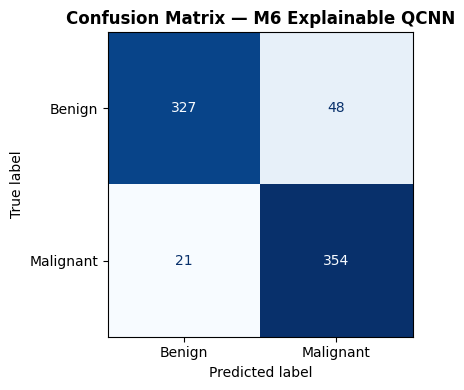

In [ ]:

# ── Full Metrics for Method 6 ────────────────────────────────
metrics_m6 = evaluate_full_metrics(model_m6, testloader, "M6 Explainable QCNN")


## Quantum Circuit Search (Genetic Algorithm)

=== Quantum Circuit Search (Genetic Algorithm) ===


--- Generation 1/3 ---

Training: GA
Epoch 1/3
Epoch 1/3
Epoch 1/3
Epoch 1/3
Epoch 1/3
Epoch 1/3
Epoch 1/3
Epoch 1/3
Epoch 1/3
Epoch 1/3
Epoch 1/3
Epoch 1/3
Epoch 1/3
Epoch 1/3
Epoch 1/3
Epoch 1/3
Epoch 1/3
Epoch 1/3
Epoch 1/3
Epoch 1/3
Epoch 1/3
Epoch 1/3
Epoch 1/3
Epoch 1/3
226/226 [==============================] - 156s 691ms/step - accuracy: 0.7514 - loss: 0.5359 - val_accuracy: 0.8307 - val_loss: 0.4590
Epoch 2/3
Epoch 2/3
Epoch 2/3
Epoch 2/3
Epoch 2/3
Epoch 2/3
Epoch 2/3
Epoch 2/3
Epoch 2/3
Epoch 2/3
Epoch 2/3
Epoch 2/3
Epoch 2/3
Epoch 2/3
Epoch 2/3
Epoch 2/3
Epoch 2/3
Epoch 2/3
Epoch 2/3
Epoch 2/3
Epoch 2/3
Epoch 2/3
Epoch 2/3
Epoch 2/3
226/226 [==============================] - 153s 678ms/step - accuracy: 0.8092 - loss: 0.4623 - val_accuracy: 0.7978 - val_loss: 0.4462
Epoch 3/3
Epoch 3/3
Epoch 3/3
Epoch 3/3
Epoch 3/3
Epoch 3/3
Epoch 3/3
Epoch 3/3
Epoch 3/3
Epoch 3/3
Epoch 3/3
Epoch 3/3
Epoch 3/3
Epoch 3/3
Epoch 3/3
Epoch 3/3


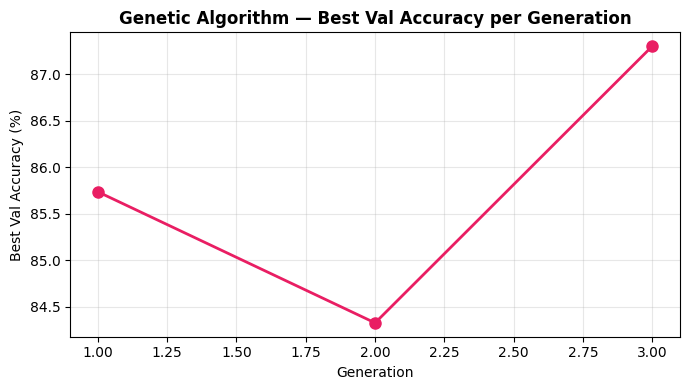

In [ ]:
import copy
import random as pyrandom

N_Q7            = 4
POPULATION_SIZE = 6
GENERATIONS     = 3
EVAL_EPOCHS     = 3
GATE_OPTIONS    = ["RY", "RZ", "RX", "H+RZ", "RY+RZ"]

alpha_m7 = alpha

def build_circuit_from_gene(gene, dev):
    @qml.qnode(dev, interface="torch")
    def dynamic_circuit(inputs, weights, enc_w):
        # Encoding — always present
        qml.AngleEmbedding(inputs * alpha_m7, wires=range(N_Q7), rotation="Y")
        # Gene-defined extra rotations
        for i, gate in enumerate(gene):
            if gate == "RY":
                qml.RY(enc_w[i] * inputs[i], wires=i)
            elif gate == "RZ":
                qml.RZ(enc_w[i] * inputs[i], wires=i)
            elif gate == "RX":
                qml.RX(enc_w[i] * inputs[i], wires=i)
            elif gate == "H+RZ":
                qml.Hadamard(wires=i)
                qml.RZ(enc_w[i] * inputs[i], wires=i)
            elif gate == "RY+RZ":
                qml.RY(enc_w[i] * inputs[i], wires=i)
                qml.RZ(enc_w[i] * inputs[i], wires=i)
        qml.StronglyEntanglingLayers(weights, wires=range(N_Q7))
        return [qml.expval(qml.PauliZ(i)) for i in range(N_Q7)]
    return dynamic_circuit

class QuantumLayer_M7(nn.Module):
    def __init__(self, gene):
        super().__init__()
        self.dev     = qml.device("default.qubit", wires=N_Q7)
        self.circuit = build_circuit_from_gene(gene, self.dev)
        self.weights = nn.Parameter(0.01 * torch.randn(3, N_Q7, 3))
        self.enc_w   = nn.Parameter(torch.ones(N_Q7))
    def forward(self, x):
        return torch.stack([
            torch.stack(self.circuit(x[i], self.weights, self.enc_w)).float()
            for i in range(x.shape[0])
        ])

class QCNN_M7(nn.Module):
    def __init__(self, gene):
        super().__init__()
        self.conv    = build_conv_block()          # shared conv block
        self.fc1     = nn.Linear(CONV_OUT_DIM, N_Q7)
        self.quantum = QuantumLayer_M7(gene)
        self.fc2     = nn.Linear(N_Q7, 1)
    def forward(self, x):
        x = self.conv(x)
        x = x.reshape(x.size(0), -1)
        x = torch.tanh(self.fc1(x)) * np.pi
        x = self.quantum(x)
        return torch.sigmoid(self.fc2(x))

def quick_fitness(gene):
    model = QCNN_M7(gene)
    _, val_accs = train_qcnn(model, epochs=EVAL_EPOCHS, label=f"GA")
    return val_accs[-1], model

def mutate(gene):
    new_gene = gene.copy()
    idx = pyrandom.randint(0, N_Q7 - 1)
    new_gene[idx] = pyrandom.choice(GATE_OPTIONS)
    return new_gene

def crossover(g1, g2):
    pt = pyrandom.randint(1, N_Q7 - 1)
    return g1[:pt] + g2[pt:]

# ── Genetic Algorithm ─────────────────────────────────────────
print("=== Quantum Circuit Search (Genetic Algorithm) ===\n")
population = [
    [pyrandom.choice(GATE_OPTIONS) for _ in range(N_Q7)]
    for _ in range(POPULATION_SIZE)
]

best_gene = None; best_fitness = 0.0; best_model_ga = None
ga_log = []

for gen in range(GENERATIONS):
    print(f"\n--- Generation {gen+1}/{GENERATIONS} ---")
    fitness_scores = []
    for gene in population:
        fit, mdl = quick_fitness(gene)
        fitness_scores.append((fit, gene, mdl))
        print(f"  Gene: {gene}  →  Val: {fit:.2f}%")
    fitness_scores.sort(key=lambda x: x[0], reverse=True)
    top_fit, top_gene, top_mdl = fitness_scores[0]
    ga_log.append(top_fit)
    if top_fit > best_fitness:
        best_fitness = top_fit; best_gene = top_gene; best_model_ga = top_mdl
    survivors = [fitness_scores[0][1], fitness_scores[1][1]]
    new_pop = survivors.copy()
    while len(new_pop) < POPULATION_SIZE:
        p1, p2 = pyrandom.sample(survivors, 2)
        new_pop.append(mutate(crossover(p1, p2)))
    population = new_pop

print(f"\nBest Gene : {best_gene}")
print(f"Best Val  : {best_fitness:.2f}%")

# Final full 20-epoch train on best gene
print("\nFinal training of best circuit for 20 epochs...")
model_m7 = QCNN_M7(best_gene)
train_acc_m7, val_acc_m7 = train_qcnn(model_m7, epochs=20, label="M7-BestCircuit")
test_acc_m7 = evaluate_model(model_m7, testloader)
print(f"\nMethod 7 (Circuit Search) — Test Accuracy: {test_acc_m7:.2f}%")

# GA evolution plot
plt.figure(figsize=(7, 4))
plt.plot(range(1, GENERATIONS+1), ga_log, "o-",
         color="#E91E63", lw=2, markersize=8)
plt.title("Genetic Algorithm — Best Val Accuracy per Generation",
          fontsize=12, fontweight="bold")
plt.xlabel("Generation"); plt.ylabel("Best Val Accuracy (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("ga_evolution.png", dpi=150, bbox_inches="tight")
plt.show()


  Metrics for: M7 Circuit Search QCNN
  Accuracy  : 92.13%
  Precision : 91.80%
  Recall    : 92.53%
  F1 Score  : 92.16%


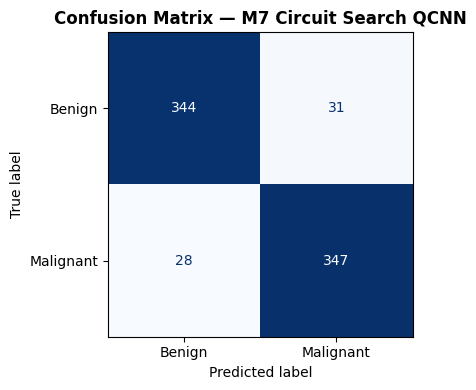

In [ ]:

# ── Full Metrics for Method 7 ────────────────────────────────
metrics_m7 = evaluate_full_metrics(model_m7, testloader, "M7 Circuit Search QCNN")


## Quantum Federated Learning

In [ ]:
import copy
N_Q8       = 4
N_CLIENTS  = 3
FED_ROUNDS = 20     # 20 rounds = equivalent to 20 epochs
dev_m8     = qml.device("default.qubit", wires=N_Q8)
alpha_m8   = alpha

@qml.qnode(dev_m8, interface="torch")
def qcirc_m8(inputs, weights, enc_w):
    qml.AngleEmbedding(inputs * alpha_m8, wires=range(N_Q8), rotation="Y")
    for i in range(N_Q8):
        theta = enc_w[i] * inputs[i]
        qml.RY(theta, wires=i)
        qml.RZ(theta, wires=i)
    qml.StronglyEntanglingLayers(weights, wires=range(N_Q8))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_Q8)]

class QuantumLayer_M8(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(0.01 * torch.randn(3, N_Q8, 3))
        self.enc_w   = nn.Parameter(torch.ones(N_Q8))
    def forward(self, x):
        return torch.stack([
            torch.stack(qcirc_m8(x[i], self.weights, self.enc_w)).float()
            for i in range(x.shape[0])
        ])

class QCNN_M8(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv    = build_conv_block()          # shared conv block
        self.fc1     = nn.Linear(CONV_OUT_DIM, N_Q8)
        self.quantum = QuantumLayer_M8()
        self.fc2     = nn.Linear(N_Q8, 1)
    def forward(self, x):
        x = self.conv(x)
        x = x.reshape(x.size(0), -1)
        x = torch.tanh(self.fc1(x)) * np.pi
        x = self.quantum(x)
        return torch.sigmoid(self.fc2(x))

def get_client_loader(client_id, n_clients=N_CLIENTS):
    total = len(X_train_t)
    shard = total // n_clients
    start = client_id * shard
    end   = start + shard if client_id < n_clients - 1 else total
    return DataLoader(TensorDataset(X_train_t[start:end],
                                    y_train_t[start:end]),
                      batch_size=BATCH, shuffle=True)

def local_train(model, loader, epochs=1):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    model.train()
    for _ in range(epochs):
        for imgs, lbls in loader:
            lbls = lbls.unsqueeze(1)
            optimizer.zero_grad()
            loss = criterion(model(imgs), lbls)
            loss.backward()
            optimizer.step()
    return model

def federated_average(global_model, client_models):
    global_dict = global_model.state_dict()
    for key in global_dict:
        global_dict[key] = torch.stack(
            [c.state_dict()[key].float() for c in client_models]
        ).mean(dim=0)
    global_model.load_state_dict(global_dict)
    return global_model

print("=== Quantum Federated Learning ===\n")
global_model   = QCNN_M8()
fed_train_accs = []
fed_val_accs   = []

for fed_round in range(FED_ROUNDS):
    print(f"\n--- Round {fed_round+1}/{FED_ROUNDS} ---")
    client_models = []
    for c in range(N_CLIENTS):
        cm = copy.deepcopy(global_model)
        cm = local_train(cm, get_client_loader(c), epochs=1)
        client_models.append(cm)
        print(f"  Client {c+1} done")
    global_model = federated_average(global_model, client_models)
    ta = evaluate_model(global_model, trainloader)
    va = evaluate_model(global_model, valloader)
    fed_train_accs.append(ta)
    fed_val_accs.append(va)
    print(f"  Global → Train: {ta:.2f}% | Val: {va:.2f}%")

train_acc_m8 = fed_train_accs
val_acc_m8   = fed_val_accs
test_acc_m8  = evaluate_model(global_model, testloader)
print(f"\nMethod 8 (Federated Learning) — Test Accuracy: {test_acc_m8:.2f}%")

=== Quantum Federated Learning ===


--- Round 1/20 ---
  Client 1 done
  Client 2 done
  Client 3 done
  Global → Train: 62.04% | Val: 62.54%

--- Round 2/20 ---
  Client 1 done
  Client 2 done
  Client 3 done
  Global → Train: 77.08% | Val: 75.86%

--- Round 3/20 ---
  Client 1 done
  Client 2 done
  Client 3 done
  Global → Train: 79.73% | Val: 77.74%

--- Round 4/20 ---
  Client 1 done
  Client 2 done
  Client 3 done
  Global → Train: 76.99% | Val: 76.49%

--- Round 5/20 ---
  Client 1 done
  Client 2 done
  Client 3 done
  Global → Train: 77.13% | Val: 75.39%

--- Round 6/20 ---
  Client 1 done
  Client 2 done
  Client 3 done
  Global → Train: 81.34% | Val: 81.35%

--- Round 7/20 ---
  Client 1 done
  Client 2 done
  Client 3 done
  Global → Train: 81.67% | Val: 80.41%

--- Round 8/20 ---
  Client 1 done
  Client 2 done
  Client 3 done
  Global → Train: 82.78% | Val: 82.76%

--- Round 9/20 ---
  Client 1 done
  Client 2 done
  Client 3 done
  Global → Train: 75.47% | Val: 71.94%




  Metrics for: M8 Federated QCNN
  Accuracy  : 76.13%
  Precision : 84.03%
  Recall    : 64.53%
  F1 Score  : 73.00%


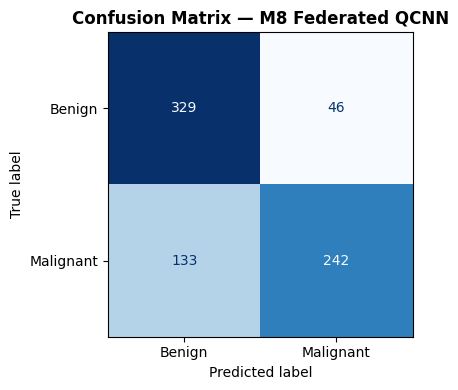

In [ ]:

# ── Full Metrics for Method 8 ────────────────────────────────
metrics_m8 = evaluate_full_metrics(global_model, testloader, "M8 Federated QCNN")


## Accuracy Curves (20 Epochs)

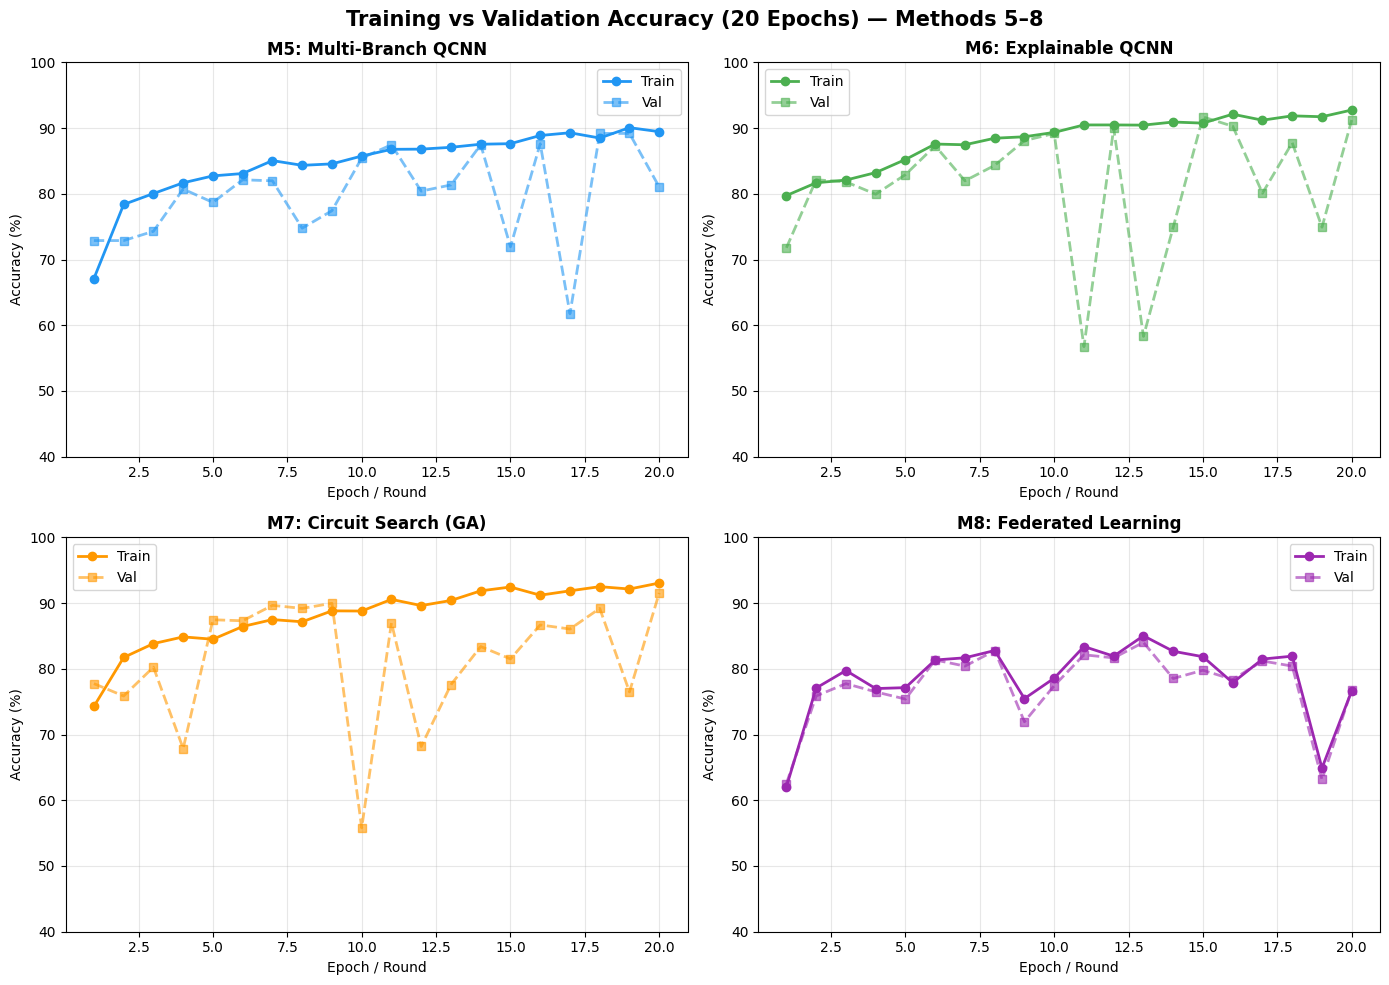

Saved: accuracy_curves_20ep.png


In [ ]:
epochs_range = range(1, 21)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Training vs Validation Accuracy (20 Epochs) — Methods 5–8",
             fontsize=15, fontweight="bold")

method_data = [
    ("M5: Multi-Branch QCNN",      train_acc_m5, val_acc_m5, "#2196F3"),
    ("M6: Explainable QCNN",       train_acc_m6, val_acc_m6, "#4CAF50"),
    ("M7: Circuit Search (GA)",    train_acc_m7, val_acc_m7, "#FF9800"),
    ("M8: Federated Learning",     train_acc_m8, val_acc_m8, "#9C27B0"),
]

for ax, (title, tr, vl, color) in zip(axes.flatten(), method_data):
    ax.plot(epochs_range, tr, "o-",  color=color,            lw=2, label="Train")
    ax.plot(epochs_range, vl, "s--", color=color, alpha=0.6, lw=2, label="Val")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Epoch / Round")
    ax.set_ylabel("Accuracy (%)")
    ax.set_ylim(40, 100)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("accuracy_curves_20ep.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: accuracy_curves_20ep.png")

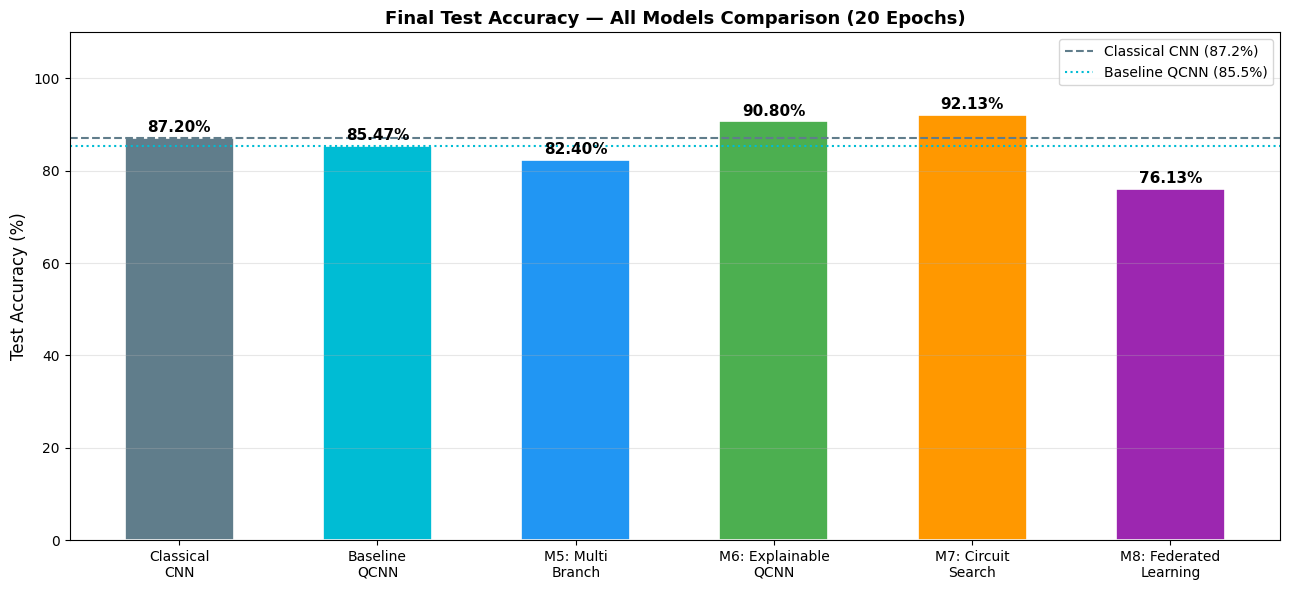


=== Final Results Summary ===
  Classical CNN                 : 87.20%
  Baseline QCNN                 : 85.47%
  M5: Multi Branch              : 82.40%
  M6: Explainable QCNN          : 90.80%
  M7: Circuit Search            : 92.13%
  M8: Federated Learning        : 76.13%


In [ ]:
results = {
    "Classical\nCNN"          : baseline_acc * 100,
    "Baseline\nQCNN"          : test_acc_base,
    "M5: Multi\nBranch"       : test_acc_m5,
    "M6: Explainable\nQCNN"   : test_acc_m6,
    "M7: Circuit\nSearch"     : test_acc_m7,
    "M8: Federated\nLearning" : test_acc_m8,
}

labels = list(results.keys())
accs   = list(results.values())
colors = ["#607D8B","#00BCD4","#2196F3","#4CAF50","#FF9800","#9C27B0"]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(labels, accs, color=colors,
              edgecolor="white", linewidth=1.2, width=0.55)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f"{acc:.2f}%",
            ha="center", va="bottom",
            fontsize=11, fontweight="bold")

ax.set_ylabel("Test Accuracy (%)", fontsize=12)
ax.set_title("Final Test Accuracy — All Models Comparison (20 Epochs)",
             fontsize=13, fontweight="bold")
ax.set_ylim(0, 110)
ax.axhline(y=baseline_acc*100, color="#607D8B", linestyle="--",
           linewidth=1.5, label=f"Classical CNN ({baseline_acc*100:.1f}%)")
ax.axhline(y=test_acc_base, color="#00BCD4", linestyle=":",
           linewidth=1.5, label=f"Baseline QCNN ({test_acc_base:.1f}%)")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("final_barplot.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== Final Results Summary ===")
for k, v in results.items():
    print(f"  {k.replace(chr(10),' '):30s}: {v:.2f}%")


  Metrics for: M8 Federated QCNN
  Accuracy  : 76.13%
  Precision : 84.03%
  Recall    : 64.53%
  F1 Score  : 73.00%


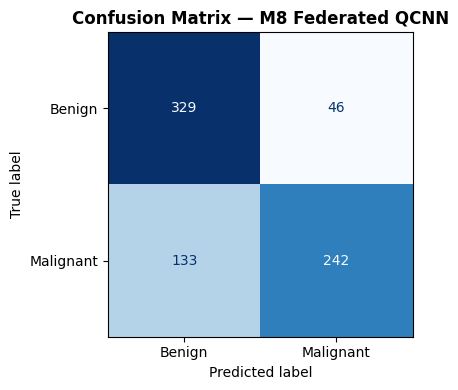

In [ ]:

# ── Full Metrics for Method 8 ────────────────────────────────
metrics_m8 = evaluate_full_metrics(global_model, testloader, "M8 Federated QCNN")


# Final Metrics Comparison — All Models


MODEL                       ACCURACY  PRECISION     RECALL   F1 SCORE
Classical CNN                 87.20%     87.40%     86.93%     87.17%
Baseline QCNN                 85.47%     96.50%     73.60%     83.51%
M5: Multi-Branch              82.40%     76.82%     92.80%     84.06%
M6: Explainable               90.80%     88.06%     94.40%     91.12%
M7: Circuit Search            92.13%     91.80%     92.53%     92.16%
M8: Federated                 76.13%     84.03%     64.53%     73.00%


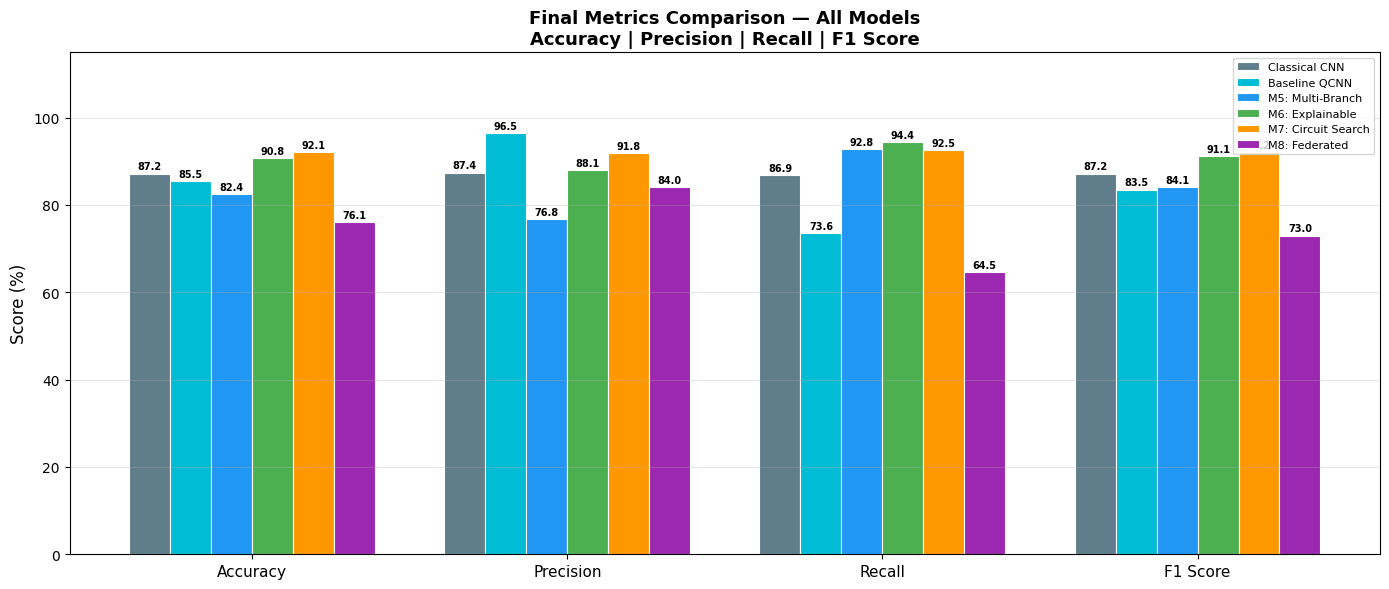

Saved: final_metrics_comparison.png


In [ ]:

# ── Final Metrics Comparison Table ───────────────────────────
import pandas as pd

all_metrics = {
    "Classical CNN"       : classical_metrics,
    "Baseline QCNN"       : baseline_metrics,
    "M5: Multi-Branch"    : metrics_m5,
    "M6: Explainable"     : metrics_m6,
    "M7: Circuit Search"  : metrics_m7,
    "M8: Federated"       : metrics_m8,
}

# Print table
print(f"\n{'='*75}")
print(f"{'MODEL':<25} {'ACCURACY':>10} {'PRECISION':>10} {'RECALL':>10} {'F1 SCORE':>10}")
print(f"{'='*75}")
for model_name, metrics in all_metrics.items():
    print(f"{model_name:<25} {metrics['accuracy']:>9.2f}%"
          f" {metrics['precision']:>9.2f}%"
          f" {metrics['recall']:>9.2f}%"
          f" {metrics['f1']:>9.2f}%")
print(f"{'='*75}")

# ── Grouped Bar Plot ──────────────────────────────────────────
metric_names  = ["Accuracy", "Precision", "Recall", "F1 Score"]
model_names   = list(all_metrics.keys())
metric_keys   = ["accuracy", "precision", "recall", "f1"]
bar_colors    = ["#607D8B", "#00BCD4", "#2196F3", "#4CAF50", "#FF9800", "#9C27B0"]

x      = np.arange(len(metric_names))
width  = 0.13
fig, ax = plt.subplots(figsize=(14, 6))

for idx, (model_name, metrics) in enumerate(all_metrics.items()):
    values = [metrics[k] for k in metric_keys]
    bars   = ax.bar(x + idx * width, values, width,
                    label=model_name, color=bar_colors[idx],
                    edgecolor="white", linewidth=0.8)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f"{bar.get_height():.1f}",
                ha="center", va="bottom", fontsize=7, fontweight="bold")

ax.set_ylabel("Score (%)", fontsize=12)
ax.set_title("Final Metrics Comparison — All Models\n"
             "Accuracy | Precision | Recall | F1 Score",
             fontsize=13, fontweight="bold")
ax.set_xticks(x + width * (len(model_names) - 1) / 2)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 115)
ax.legend(loc="upper right", fontsize=8)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("final_metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: final_metrics_comparison.png")
